<!-- CODEx Chinese cell explanation: start -->
### Cell 01 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 01 — Computational step 01

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [1]:


from pathlib import Path
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.model_selection import KFold

plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
})

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = PROJECT_ROOT / "outputs_step2"
STEP3_DIR = PROJECT_ROOT / "outputs_step3"
OUT_DIR = PROJECT_ROOT / "outputs_step4"
FIG_DIR = OUT_DIR / "figures"
MODEL_DIR = OUT_DIR / "models"
for p in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET_PATH = DATA_DIR / "step1_simulation_dataset.csv"
SRC_PATH = STEP2_DIR / "src_indices_bootstrap.csv"
BEST2_PATH = STEP3_DIR / "best2_models.csv"
FAST_MODE = os.environ.get("EUI_FAST_MODE", "0") == "1"
BOOTSTRAP_N = 100 if FAST_MODE else 1000
CARBON_CV_SPLITS = 3 if FAST_MODE else 10


<!-- CODEx Chinese cell explanation: start -->
### Cell 02 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 02 — Computational step 02

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [2]:
# ---------- 1) Configure carbon-emission factors ----------
# Unit: kgCO2e / kWh.
# Replace these first with the final Beijing region, target year, and official accounting boundary used in the study.
EMISSION_FACTORS = {
    "electricity": 0.55,
    "natural_gas": 0.202,
    "district_heating": 0.22,
    "district_cooling": 0.16,
}

# ---------- Fixed carbon-accounting boundary ----------
# This section no longer compares multiple scenarios; it studies EUI-OCEI coupling under one unified carbon-accounting boundary:
# 1) Space heating -> district_heating.
# 2) Space cooling -> district_cooling.
# 3) Domestic hot water -> natural_gas.
# 4) Building-side electricity loads such as lighting, equipment, and fans -> electricity.
SHOW_ZERO_CARRIERS = True

EMISSION_FACTORS

{'electricity': 0.55,
 'natural_gas': 0.202,
 'district_heating': 0.22,
 'district_cooling': 0.16}

### Emission-factor sources and accounting notes

**Response to the reviewer request for emission-factor provenance and sensitivity testing.** The OCEI calculation uses carrier-specific factors for electricity, natural gas, district heating, and district cooling. Electricity is treated as the most influential and policy-sensitive factor, so the notebook evaluates low-grid, high-grid, and decarbonisation scenarios in addition to the baseline case.

The sensitivity analysis distinguishes two claims: absolute OCEI values change with emission-factor assumptions, whereas the EUI-OCEI correlation and top-rank overlap are used to assess whether the coupling structure remains robust under plausible factor changes.

<!-- CODEx Chinese cell explanation: start -->
### Cell 03 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 03 — Computational step 03

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [3]:
# ---------- 2) Load data, build carbon labels, and complete feature engineering ----------
assert DATASET_PATH.exists(), "Please complete Step 1 first"
assert SRC_PATH.exists(), "Please complete Step 2 first"
assert BEST2_PATH.exists(), "Please complete Step 3 first"

df = pd.read_csv(DATASET_PATH)
src_df = pd.read_csv(SRC_PATH)
best2 = pd.read_csv(BEST2_PATH).iloc[:, 0].tolist()

# ---------- A) Use feature engineering consistent with Steps 2 and 3 ----------
if "orientation_deg" in df.columns:
    df["orientation_sin"] = np.sin(np.deg2rad(df["orientation_deg"]))
    df["orientation_cos"] = np.cos(np.deg2rad(df["orientation_deg"]))

if "window_type_id" in df.columns:
    df = pd.get_dummies(df, columns=["window_type_id"], prefix="window_type", drop_first=True)

# Ensure that dummy columns exist.
for col in ["window_type_2", "window_type_3"]:
    if col not in df.columns:
        df[col] = 0

# Recalculate footprint_area_m2 and aspect_ratio if they are missing from the raw data.
if "footprint_area_m2" not in df.columns and {"building_length", "building_width"}.issubset(df.columns):
    df["footprint_area_m2"] = df["building_length"] * df["building_width"]

if "aspect_ratio" not in df.columns and {"building_length", "building_width"}.issubset(df.columns):
    df["aspect_ratio"] = df["building_length"] / df["building_width"].replace(0, np.nan)

# ---------- B) Build carbon-emission labels under the fixed accounting boundary ----------
for col in [
    "electricity_kwh", "natural_gas_kwh",
    "district_heating_kwh", "district_cooling_kwh",
    "lighting_electricity_kwh", "equipment_electricity_kwh", "fan_electricity_kwh",
    "ideal_heating_load_kwh", "ideal_cooling_load_kwh", "dhw_thermal_kwh"
]:
    if col not in df.columns:
        df[col] = 0.0
    df[col] = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Fixed boundary:
# Space heating -> district heating.
# Space cooling -> district cooling.
# Domestic hot water -> natural gas.
# Building-side electricity loads -> lighting + equipment + fans.
df["electricity_kwh_for_carbon"] = (
    df["lighting_electricity_kwh"] +
    df["equipment_electricity_kwh"] +
    df["fan_electricity_kwh"]
)

df["natural_gas_kwh_for_carbon"] = df["natural_gas_kwh"]
df["district_heating_kwh_for_carbon"] = df["ideal_heating_load_kwh"]
df["district_cooling_kwh_for_carbon"] = df["ideal_cooling_load_kwh"]

df["carbon_kgco2e"] = (
    df["electricity_kwh_for_carbon"] * EMISSION_FACTORS["electricity"] +
    df["natural_gas_kwh_for_carbon"] * EMISSION_FACTORS["natural_gas"] +
    df["district_heating_kwh_for_carbon"] * EMISSION_FACTORS["district_heating"] +
    df["district_cooling_kwh_for_carbon"] * EMISSION_FACTORS["district_cooling"]
)

df["OCEI_kgco2e_m2"] = df["carbon_kgco2e"] / df["gross_floor_area_m2"]

df["OCEI_electricity"] = (
    df["electricity_kwh_for_carbon"] * EMISSION_FACTORS["electricity"] / df["gross_floor_area_m2"]
)
df["OCEI_natural_gas"] = (
    df["natural_gas_kwh_for_carbon"] * EMISSION_FACTORS["natural_gas"] / df["gross_floor_area_m2"]
)
df["OCEI_district_heating"] = (
    df["district_heating_kwh_for_carbon"] * EMISSION_FACTORS["district_heating"] / df["gross_floor_area_m2"]
)
df["OCEI_district_cooling"] = (
    df["district_cooling_kwh_for_carbon"] * EMISSION_FACTORS["district_cooling"] / df["gross_floor_area_m2"]
)

df["site_energy_kwh_for_carbon"] = (
    df["electricity_kwh_for_carbon"] +
    df["natural_gas_kwh_for_carbon"] +
    df["district_heating_kwh_for_carbon"] +
    df["district_cooling_kwh_for_carbon"]
)

df["carbon_per_kwh"] = df["carbon_kgco2e"] / df["site_energy_kwh_for_carbon"].replace(0, np.nan)

df[[
    "sample_id",
    "eui_kwh_m2",
    "OCEI_kgco2e_m2",
    "carbon_per_kwh",
    "electricity_kwh",
    "natural_gas_kwh"
]].head(99)

,sample_id,eui_kwh_m2,OCEI_kgco2e_m2,carbon_per_kwh,electricity_kwh,natural_gas_kwh
0,sample_0004,164.216609,49.187608,0.225520,251871.129126,9.421360e+05
1,sample_0007,98.708840,38.155514,0.251236,388429.626663,4.443512e+05
2,sample_0009,160.571733,49.087892,0.225370,342160.897954,8.758682e+05
3,sample_0010,193.500793,58.462605,0.231365,294938.718660,8.701560e+05
4,sample_0011,165.278937,49.889815,0.227732,339522.197398,1.134847e+06
...,...,...,...,...,...,...
94,sample_0397,160.192173,48.992007,0.226984,270037.003879,6.880388e+05
95,sample_0398,191.398637,58.967481,0.229755,294079.923471,8.820545e+05
96,sample_0401,173.281799,52.701463,0.229499,242565.618207,7.822647e+05
97,sample_0402,160.025213,51.199272,0.243837,397229.198416,9.580750e+05


<!-- CODEx Chinese cell explanation: start -->
### Cell 04 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 04 — Computational step 04

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

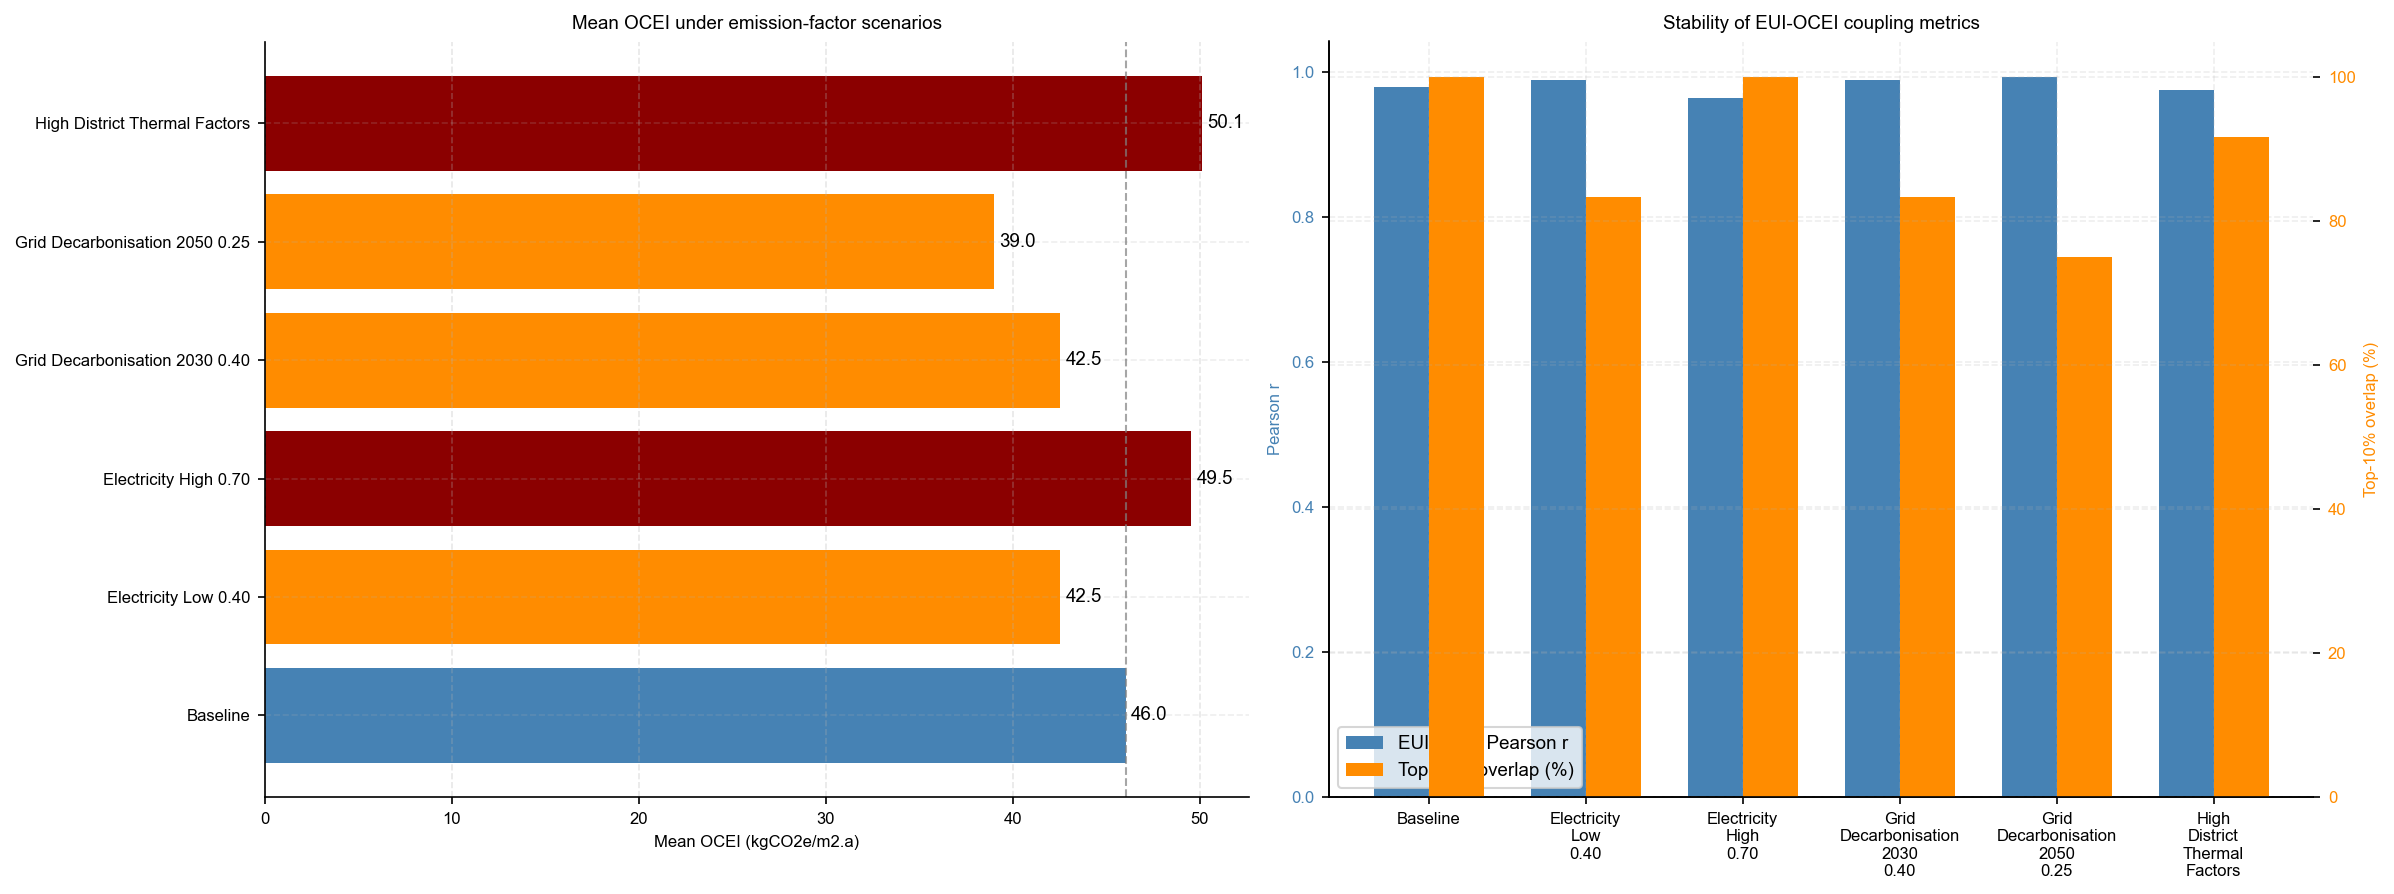

EMISSION FACTOR SENSITIVITY ANALYSIS


,scenario,mean_ocei,std_ocei,corr_with_baseline_ocei,eui_ocei_pearson_r,eui_ocei_pearson_p,top10_overlap_with_baseline,electricity_share,natural_gas_share,district_heating_share,district_cooling_share
0,Baseline,46.0342,7.5022,1.0000,0.9791,0.0,1.0000,0.2835,0.4121,0.1202,0.1843
1,Electricity Low 0.40,42.5189,7.4091,0.9972,0.9886,0.0,0.8333,0.2234,0.4466,0.1302,0.1997
2,Electricity High 0.70,49.5496,7.6368,0.9973,0.9646,0.0,1.0000,0.3349,0.3825,0.1115,0.1711
3,Grid Decarbonisation 2030 0.40,42.5189,7.4091,0.9972,0.9886,0.0,0.8333,0.2234,0.4466,0.1302,0.1997
4,Grid Decarbonisation 2050 0.25,39.0035,7.3589,0.9884,0.9925,0.0,0.7500,0.1524,0.4874,0.1421,0.2180
5,High District Thermal Factors,50.1251,7.5935,0.9993,0.9755,0.0,0.9167,0.2601,0.3781,0.1504,0.2114



Baseline OCEI: 46.03 ± 7.50
EUI-OCEI correlation range: [0.9646, 0.9925]
Electricity share range: [15.2%, 33.5%]
Natural gas share range: [37.8%, 48.7%]


In [4]:
# ============================================================
# [IMPROVEMENT P0-3] Carbon Emission Factor Sensitivity Analysis
# Tests robustness of EUI-OCEI coupling under alternative factors.
# ============================================================

from scipy.stats import pearsonr

scenarios = {
    'Baseline': {
        'electricity': 0.55, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'Electricity Low 0.40': {
        'electricity': 0.40, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'Electricity High 0.70': {
        'electricity': 0.70, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'Grid Decarbonisation 2030 0.40': {
        'electricity': 0.40, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'Grid Decarbonisation 2050 0.25': {
        'electricity': 0.25, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'High District Thermal Factors': {
        'electricity': 0.55, 'natural_gas': 0.202,
        'district_heating': 0.30, 'district_cooling': 0.20
    },
}

scenario_results = []
scenario_ocei = {}

for sc_name, ef in scenarios.items():
    carrier_carbon = pd.DataFrame({
        'electricity': df['electricity_kwh_for_carbon'] * ef['electricity'],
        'natural_gas': df['natural_gas_kwh_for_carbon'] * ef['natural_gas'],
        'district_heating': df['district_heating_kwh_for_carbon'] * ef['district_heating'],
        'district_cooling': df['district_cooling_kwh_for_carbon'] * ef['district_cooling'],
    })
    ocei_sc = carrier_carbon.sum(axis=1) / df['gross_floor_area_m2']
    scenario_ocei[sc_name] = ocei_sc

    r_eui, p_eui = pearsonr(df['eui_kwh_m2'], ocei_sc)
    rank_base = df['OCEI_kgco2e_m2'].rank(method='first', ascending=True)
    rank_sc = ocei_sc.rank(method='first', ascending=True)
    top_n = max(1, int(len(df) * 0.10))
    overlap = len(set(rank_base.nsmallest(top_n).index) & set(rank_sc.nsmallest(top_n).index)) / top_n

    total_by_carrier = carrier_carbon.sum()
    share_by_carrier = total_by_carrier / total_by_carrier.sum()

    scenario_results.append({
        'scenario': sc_name,
        'mean_ocei': ocei_sc.mean(),
        'std_ocei': ocei_sc.std(),
        'corr_with_baseline_ocei': ocei_sc.corr(df['OCEI_kgco2e_m2']),
        'eui_ocei_pearson_r': r_eui,
        'eui_ocei_pearson_p': p_eui,
        'top10_overlap_with_baseline': overlap,
        'electricity_share': share_by_carrier['electricity'],
        'natural_gas_share': share_by_carrier['natural_gas'],
        'district_heating_share': share_by_carrier['district_heating'],
        'district_cooling_share': share_by_carrier['district_cooling'],
    })

scenario_df = pd.DataFrame(scenario_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

ax = axes[0]
baseline_mean = scenario_df.loc[scenario_df['scenario'] == 'Baseline', 'mean_ocei'].values[0]
colors = ['steelblue' if s == 'Baseline' else 'darkorange' if 'Low' in s or '2030' in s or '2050' in s
          else 'darkred' if 'High' in s else 'grey' for s in scenario_df['scenario']]
bars = ax.barh(scenario_df['scenario'], scenario_df['mean_ocei'], color=colors)
ax.axvline(baseline_mean, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Mean OCEI (kgCO2e/m2.a)')
ax.set_title('Mean OCEI under emission-factor scenarios')
for bar, val in zip(bars, scenario_df['mean_ocei']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
x = np.arange(len(scenario_df))
width = 0.35
ax.bar(x - width/2, scenario_df['eui_ocei_pearson_r'], width,
       label='EUI-OCEI Pearson r', color='steelblue')
ax.set_ylabel('Pearson r', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax.twinx()
ax2.bar(x + width/2, scenario_df['top10_overlap_with_baseline'] * 100, width,
        label='Top-10% overlap (%)', color='darkorange')
ax2.set_ylabel('Top-10% overlap (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax.set_xticks(x)
ax.set_xticklabels([s.replace(' ', '\n') for s in scenario_df['scenario']], rotation=0, ha='center', fontsize=8)
ax.set_title('Stability of EUI-OCEI coupling metrics')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')

plt.tight_layout()
fig.savefig(FIG_DIR / 'emission_factor_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

scenario_df.to_csv(OUT_DIR / 'emission_factor_sensitivity.csv', index=False, encoding='utf-8-sig')

print("=" * 70)
print("EMISSION FACTOR SENSITIVITY ANALYSIS")
print("=" * 70)
display(scenario_df.round(4))
print(f"\nBaseline OCEI: {baseline_mean:.2f} ± "
      f"{scenario_df.loc[scenario_df['scenario']=='Baseline','std_ocei'].values[0]:.2f}")
print(f"EUI-OCEI correlation range: "
      f"[{scenario_df['eui_ocei_pearson_r'].min():.4f}, {scenario_df['eui_ocei_pearson_r'].max():.4f}]")
print(f"Electricity share range: "
      f"[{scenario_df['electricity_share'].min()*100:.1f}%, {scenario_df['electricity_share'].max()*100:.1f}%]")
print(f"Natural gas share range: "
      f"[{scenario_df['natural_gas_share'].min()*100:.1f}%, {scenario_df['natural_gas_share'].max()*100:.1f}%]")


<!-- CODEx Chinese cell explanation: start -->
### Cell 05 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 05 — Computational step 05

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

,mean_ocei,median_ocei,std_ocei,min_ocei,max_ocei
0,46.0342,46.205,7.5022,29.5519,69.703


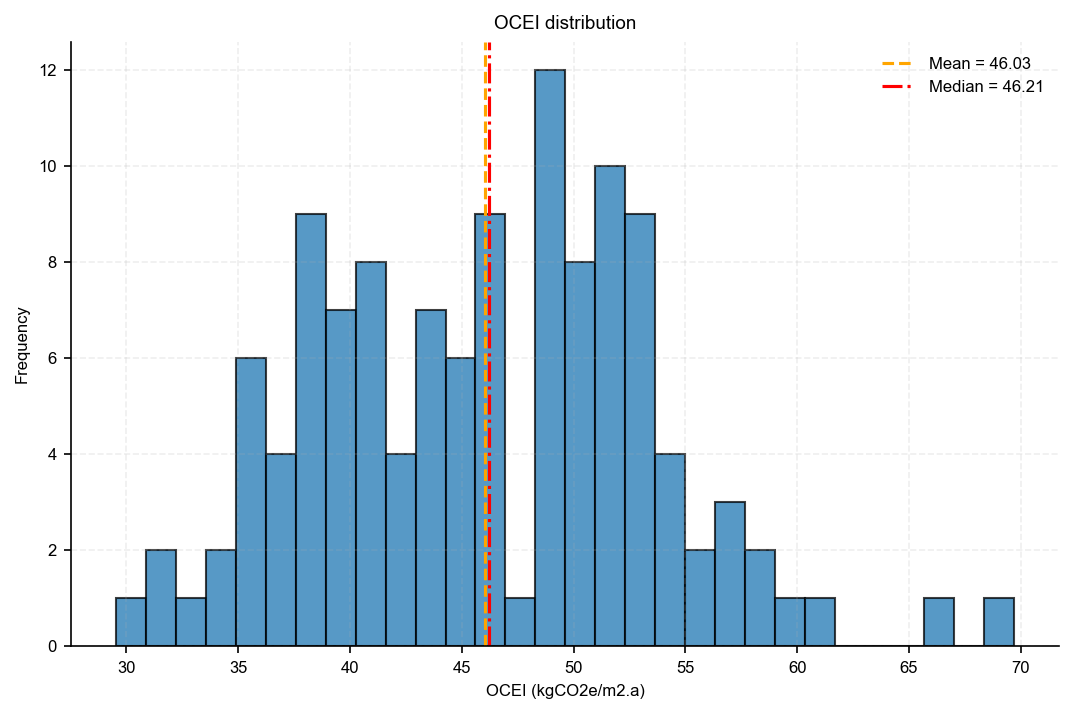

In [5]:
# ---------- 2A) OCEI distribution and statistics ----------
ocei_stats = pd.DataFrame([{
    "mean_ocei": df["OCEI_kgco2e_m2"].mean(),
    "median_ocei": df["OCEI_kgco2e_m2"].median(),
    "std_ocei": df["OCEI_kgco2e_m2"].std(),
    "min_ocei": df["OCEI_kgco2e_m2"].min(),
    "max_ocei": df["OCEI_kgco2e_m2"].max(),
}])

ocei_stats.to_csv(OUT_DIR / "ocei_summary_statistics.csv", index=False, encoding="utf-8-sig")
display(ocei_stats.round(4))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.hist(df["OCEI_kgco2e_m2"].dropna(), bins=30, edgecolor="black", alpha=0.75)
ax.axvline(df["OCEI_kgco2e_m2"].mean(), linestyle="--", linewidth=1.5, label=f"Mean = {df['OCEI_kgco2e_m2'].mean():.2f}",color = 'orange')
ax.axvline(df["OCEI_kgco2e_m2"].median(), linestyle="-.", linewidth=1.5, label=f"Median = {df['OCEI_kgco2e_m2'].median():.2f}", color ='red')
ax.set_title("OCEI distribution")
ax.set_xlabel("OCEI (kgCO2e/m2.a)")
ax.set_ylabel("Frequency")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "ocei_distribution.png", bbox_inches="tight")
plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 06 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 06 — Computational step 06

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [6]:
# ---------- 2B) Multi-scenario OCEI calculation function ----------
def build_carbon_dataset(dataset_path, scenario="baseline", heat_mode="space_only", emission_factors=None):
    if emission_factors is None:
        emission_factors = EMISSION_FACTORS

    d = pd.read_csv(dataset_path)

    # Use feature engineering consistent with the earlier steps.
    if "orientation_deg" in d.columns:
        d["orientation_sin"] = np.sin(np.deg2rad(d["orientation_deg"]))
        d["orientation_cos"] = np.cos(np.deg2rad(d["orientation_deg"]))

    if "window_type_id" in d.columns:
        d = pd.get_dummies(d, columns=["window_type_id"], prefix="window_type", drop_first=True)

    for col in ["window_type_2", "window_type_3"]:
        if col not in d.columns:
            d[col] = 0

    if "footprint_area_m2" not in d.columns and {"building_length", "building_width"}.issubset(d.columns):
        d["footprint_area_m2"] = d["building_length"] * d["building_width"]

    if "aspect_ratio" not in d.columns and {"building_length", "building_width"}.issubset(d.columns):
        d["aspect_ratio"] = d["building_length"] / d["building_width"].replace(0, np.nan)

    for col in [
        "electricity_kwh", "natural_gas_kwh",
        "district_heating_kwh", "district_cooling_kwh",
        "lighting_electricity_kwh", "equipment_electricity_kwh", "fan_electricity_kwh",
        "ideal_heating_load_kwh", "ideal_cooling_load_kwh", "dhw_thermal_kwh"
    ]:
        if col not in d.columns:
            d[col] = 0.0
        d[col] = pd.to_numeric(d[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)

    if scenario == "baseline":
        d["electricity_kwh_for_carbon"] = d["electricity_kwh"]
        d["natural_gas_kwh_for_carbon"] = d["natural_gas_kwh"]
        d["district_heating_kwh_for_carbon"] = d["district_heating_kwh"]
        d["district_cooling_kwh_for_carbon"] = d["district_cooling_kwh"]

    elif scenario == "district":
        d["electricity_kwh_for_carbon"] = (
            d["lighting_electricity_kwh"] +
            d["equipment_electricity_kwh"] +
            d["fan_electricity_kwh"]
        )
        d["district_cooling_kwh_for_carbon"] = d["ideal_cooling_load_kwh"]

        if heat_mode == "space_plus_dhw":
            d["natural_gas_kwh_for_carbon"] = 0.0
            d["district_heating_kwh_for_carbon"] = d["ideal_heating_load_kwh"] + d["dhw_thermal_kwh"]
        elif heat_mode == "space_only":
            d["natural_gas_kwh_for_carbon"] = d["natural_gas_kwh"]
            d["district_heating_kwh_for_carbon"] = d["ideal_heating_load_kwh"]
        else:
            raise ValueError(f"Unknown heat_mode: {heat_mode}")
    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    d["carbon_kgco2e"] = (
        d["electricity_kwh_for_carbon"] * emission_factors["electricity"] +
        d["natural_gas_kwh_for_carbon"] * emission_factors["natural_gas"] +
        d["district_heating_kwh_for_carbon"] * emission_factors["district_heating"] +
        d["district_cooling_kwh_for_carbon"] * emission_factors["district_cooling"]
    )

    d["OCEI_kgco2e_m2"] = d["carbon_kgco2e"] / d["gross_floor_area_m2"]

    d["site_energy_kwh_for_carbon"] = (
        d["electricity_kwh_for_carbon"] +
        d["natural_gas_kwh_for_carbon"] +
        d["district_heating_kwh_for_carbon"] +
        d["district_cooling_kwh_for_carbon"]
    )

    d["carbon_per_kwh"] = d["carbon_kgco2e"] / d["site_energy_kwh_for_carbon"].replace(0, np.nan)

    d["scenario_name"] = scenario if scenario == "baseline" else f"{scenario}_{heat_mode}"
    return d

<!-- CODEx Chinese cell explanation: start -->
### Cell 07 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 07 — Computational step 07

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [7]:
# ---------- 3) Load the top 18 variables and rebuild the top two models ----------
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

top18 = src_df.sort_values("abs_SRC", ascending=False).head(18)["feature"].tolist()

missing = [c for c in top18 if c not in df.columns]
if missing:
    raise KeyError(f"Top18 features missing after feature engineering: {missing}")

X = df[top18].copy()
y = pd.to_numeric(df["OCEI_kgco2e_m2"], errors="coerce").replace([np.inf, -np.inf], np.nan)
valid_ocei_mask = np.isfinite(y.to_numpy())
if not valid_ocei_mask.all():
    print(f"Dropping rows with missing or non-finite OCEI: {(~valid_ocei_mask).sum()}")
X = X.loc[valid_ocei_mask].reset_index(drop=True)
y = y.loc[valid_ocei_mask].reset_index(drop=True)

prep_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

prep_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

alphas = np.logspace(-4, 4, 40)

models = {
    "Linear": Pipeline([
        ("prep", prep_linear),
        ("model", LinearRegression())
    ]),

    "RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("model", RidgeCV(alphas=alphas, cv=10))
    ]),

    "LassoCV": Pipeline([
        ("prep", prep_linear),
        ("model", LassoCV(alphas=alphas, cv=10, max_iter=50000, random_state=42))
    ]),

    "ElasticNetCV": Pipeline([
        ("prep", prep_linear),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=alphas,
            cv=10,
            max_iter=50000,
            random_state=42
        ))
    ]),

    "Poly2-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-2, 4, 30), cv=10))
    ]),

    "Poly2-ElasticNetCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=np.logspace(-3, 2, 20),
            cv=10,
            max_iter=50000,
            random_state=42
        ))
    ]),

    "Poly2-Interaction-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-2, 4, 30), cv=10))
    ]),

    "Poly3-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-1, 5, 30), cv=10))
    ]),

    "KNN": Pipeline([
        ("prep", prep_linear),
        ("model", KNeighborsRegressor(n_neighbors=8, weights="distance"))
    ]),

    "SVR-RBF": Pipeline([
        ("prep", prep_linear),
        ("model", SVR(C=20.0, epsilon=0.02, kernel="rbf", gamma="scale"))
    ]),

    "DecisionTree": Pipeline([
        ("prep", prep_tree),
        ("model", DecisionTreeRegressor(max_depth=8, min_samples_leaf=4, random_state=42))
    ]),

    "RandomForest": Pipeline([
        ("prep", prep_tree),
        ("model", RandomForestRegressor(
            n_estimators=800,
            max_depth=8,
            min_samples_leaf=2,
            min_samples_split=4,
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "ExtraTrees": Pipeline([
        ("prep", prep_tree),
        ("model", ExtraTreesRegressor(
            n_estimators=800,
            max_depth=8,
            min_samples_leaf=2,
            min_samples_split=4,
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "GB": Pipeline([
        ("prep", prep_tree),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),

    "MLP": Pipeline([
        ("prep", prep_linear),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            alpha=1e-3,
            random_state=42,
            max_iter=5000
        ))
    ]),
}

if HAS_XGB:
    models["XGBoost"] = Pipeline([
        ("prep", prep_tree),
        ("model", XGBRegressor(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ])

if HAS_LGBM:
    models["LightGBM"] = Pipeline([
        ("prep", prep_tree),
        ("model", LGBMRegressor(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=15,
            min_child_samples=10,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42
        ))
    ])

models_for_carbon = {name: models[name] for name in best2 if name in models}

print("Best2 from step3:", best2)
print("Available models:", list(models.keys()))
print("Carbon models selected:", list(models_for_carbon.keys()))

Best2 from step3: ['RidgeCV', 'ElasticNetCV']
Available models: ['Linear', 'RidgeCV', 'LassoCV', 'ElasticNetCV', 'Poly2-RidgeCV', 'Poly2-ElasticNetCV', 'Poly2-Interaction-RidgeCV', 'Poly3-RidgeCV', 'KNN', 'SVR-RBF', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GB', 'MLP', 'XGBoost', 'LightGBM']
Carbon models selected: ['RidgeCV', 'ElasticNetCV']


<!-- CODEx Chinese cell explanation: start -->
### Cell 08 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 08 — Computational step 08

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [8]:
# ---------- 4) Evaluate carbon-intensity prediction by the top two models ----------
cv = KFold(n_splits=CARBON_CV_SPLITS, shuffle=True, random_state=42)
carbon_metrics = []
carbon_oof = {}

for name, estimator in models_for_carbon.items():
    oof = np.full(len(X), np.nan)
    fold_r2_scores = []

    for tr, te in cv.split(X):
        est = clone(estimator)
        est.fit(X.iloc[tr], y.iloc[tr])
        pred_fold = est.predict(X.iloc[te])

        oof[te] = pred_fold
        fold_r2_scores.append(r2_score(y.iloc[te], pred_fold))

    carbon_oof[name] = oof
    carbon_metrics.append({
        "model": name,
        "R2": r2_score(y, oof),
        "cv_r2_mean": np.mean(fold_r2_scores),
        "cv_r2_std": np.std(fold_r2_scores, ddof=1),
        "cv_r2_variance": np.var(fold_r2_scores, ddof=1),
        "RMSE": np.sqrt(mean_squared_error(y, oof)),
        "MAE": mean_absolute_error(y, oof),
        "MAPE": mean_absolute_percentage_error(y, oof),
    })

carbon_metrics_df = pd.DataFrame(carbon_metrics)
carbon_metrics_df = carbon_metrics_df.sort_values(["R2", "cv_r2_variance"], ascending=[False, True]).reset_index(drop=True)
carbon_metrics_df.to_csv(OUT_DIR / "carbon_model_metrics.csv", index=False, encoding="utf-8-sig")
carbon_metrics_df

,model,R2,cv_r2_mean,cv_r2_std,cv_r2_variance,RMSE,MAE,MAPE
0,RidgeCV,0.934694,0.934074,0.009919,0.000098,1.909252,1.487813,0.032709
1,ElasticNetCV,0.933061,0.932363,0.009603,0.000092,1.932982,1.496706,0.033003


<!-- CODEx Chinese cell explanation: start -->
### Cell 09 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 09 — Computational step 09

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

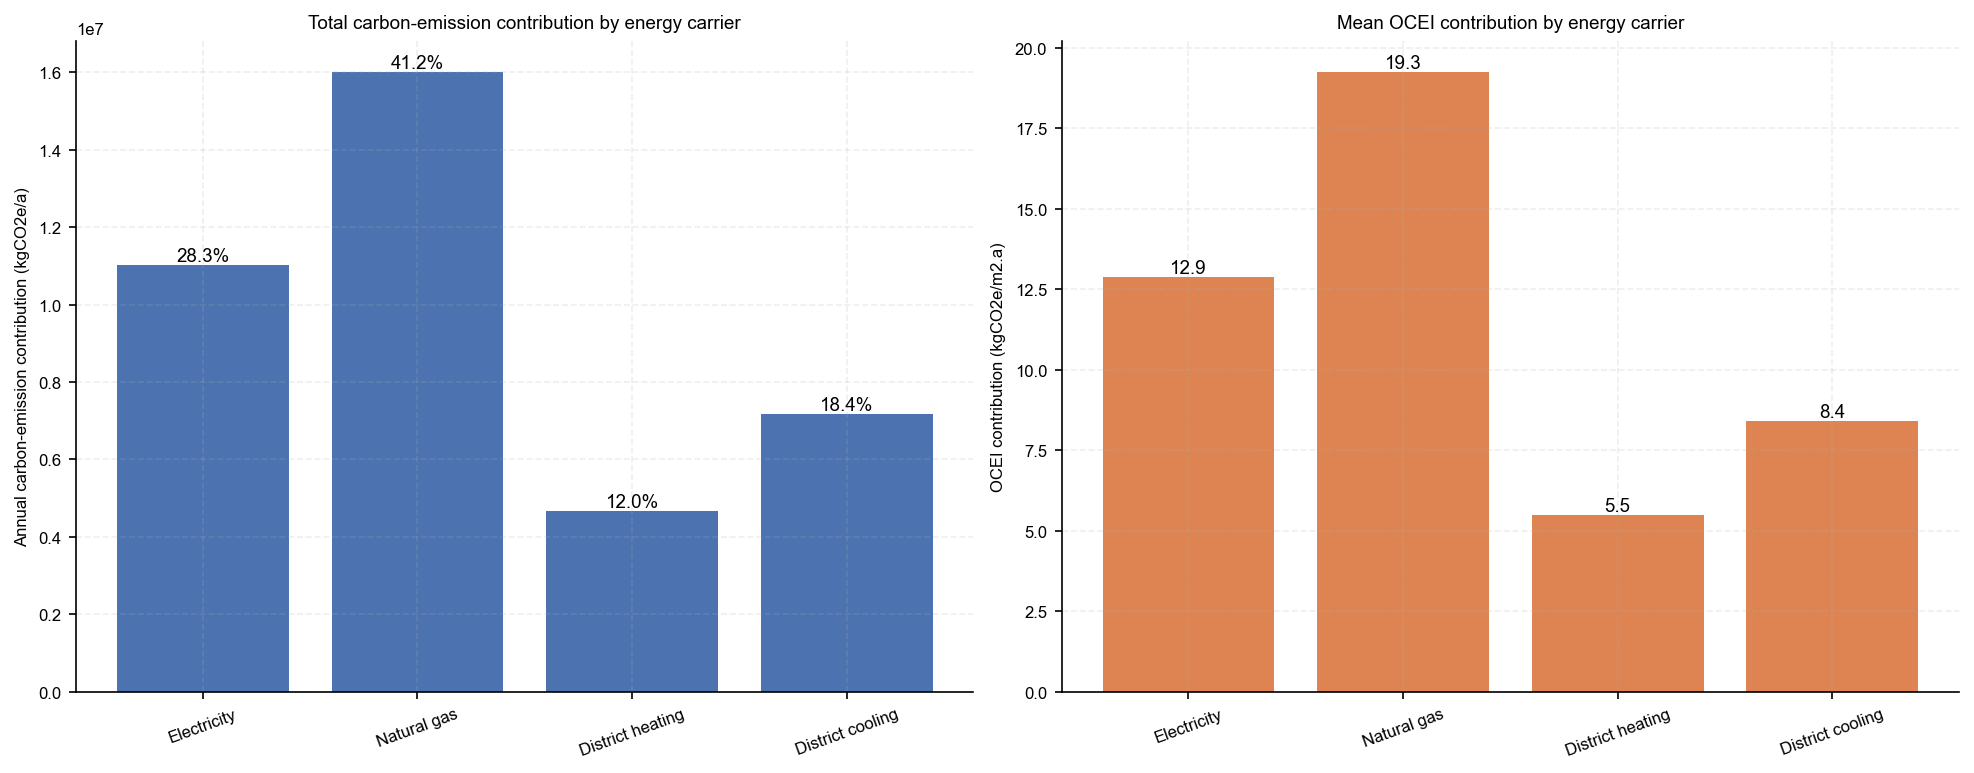

,carrier,carrier_zh,total_carbon_kgco2e,avg_carbon_kgco2e_per_sample,avg_ocei_kgco2e_m2,share
0,electricity,Electricity,1.102116e+07,91083.9877,12.8896,0.2835
1,natural_gas,Natural gas,1.602073e+07,132402.7393,19.2686,0.4121
2,district_heating,District heating,4.671668e+06,38608.8279,5.4725,0.1202
3,district_cooling,District cooling,7.165571e+06,59219.5929,8.4035,0.1843


In [9]:
# ---------- 5) Consolidated dual-view carbon contribution figure ----------
carrier_carbon_total = pd.Series({
    "electricity": (df["electricity_kwh_for_carbon"] * EMISSION_FACTORS["electricity"]).sum(),
    "natural_gas": (df["natural_gas_kwh_for_carbon"] * EMISSION_FACTORS["natural_gas"]).sum(),
    "district_heating": (df["district_heating_kwh_for_carbon"] * EMISSION_FACTORS["district_heating"]).sum(),
    "district_cooling": (df["district_cooling_kwh_for_carbon"] * EMISSION_FACTORS["district_cooling"]).sum(),
}, dtype=float).reindex(["electricity", "natural_gas", "district_heating", "district_cooling"]).fillna(0.0)

carrier_labels_zh = {
    "electricity": "Electricity",
    "natural_gas": "Natural gas",
    "district_heating": "District heating",
    "district_cooling": "District cooling",
}

carrier_ocei_avg = pd.Series({
    carrier: (df[f"{carrier}_kwh_for_carbon"] * EMISSION_FACTORS[carrier] / df["gross_floor_area_m2"]).mean()
    for carrier in carrier_carbon_total.index
}, dtype=float)
carrier_share = carrier_carbon_total / carrier_carbon_total.sum()

carbon_breakdown_df = pd.DataFrame({
    "carrier": carrier_carbon_total.index,
    "carrier_zh": [carrier_labels_zh[c] for c in carrier_carbon_total.index],
    "total_carbon_kgco2e": carrier_carbon_total.values,
    "avg_carbon_kgco2e_per_sample": (carrier_carbon_total / len(df)).values,
    "avg_ocei_kgco2e_m2": carrier_ocei_avg.values,
    "share": carrier_share.values,
})
carbon_breakdown_df.to_csv(OUT_DIR / "carbon_breakdown_by_carrier.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), dpi=150)

ax = axes[0]
bars = ax.bar(carbon_breakdown_df["carrier_zh"], carbon_breakdown_df["total_carbon_kgco2e"], color="#4C72B0")
ax.set_title("Total carbon-emission contribution by energy carrier")
ax.set_ylabel("Annual carbon-emission contribution (kgCO2e/a)")
ax.tick_params(axis="x", rotation=20)
for bar, share in zip(bars, carbon_breakdown_df["share"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{share*100:.1f}%", ha="center", va="bottom", fontsize=9)

ax = axes[1]
bars = ax.bar(carbon_breakdown_df["carrier_zh"], carbon_breakdown_df["avg_ocei_kgco2e_m2"], color="#DD8452")
ax.set_title("Mean OCEI contribution by energy carrier")
ax.set_ylabel("OCEI contribution (kgCO2e/m2.a)")
ax.tick_params(axis="x", rotation=20)
for bar, val in zip(bars, carbon_breakdown_df["avg_ocei_kgco2e_m2"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "carbon_contribution_dual_view.png", dpi=300, bbox_inches="tight")
plt.show()

display(carbon_breakdown_df.round(4))


<!-- CODEx Chinese cell explanation: start -->
### Cell 10 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 10 — Computational step 10

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [10]:
# ---------- 5-Table) Carbon-contribution table display ----------
if "carbon_breakdown_df" not in globals():
    raise RuntimeError("Run the consolidated dual-view carbon-contribution cell first.")

display_cols = [
    "carrier", "carrier_zh", "total_carbon_kgco2e",
    "avg_carbon_kgco2e_per_sample", "avg_ocei_kgco2e_m2", "share"
]
display(carbon_breakdown_df[display_cols].round(4))


,carrier,carrier_zh,total_carbon_kgco2e,avg_carbon_kgco2e_per_sample,avg_ocei_kgco2e_m2,share
0,electricity,Electricity,1.102116e+07,91083.9877,12.8896,0.2835
1,natural_gas,Natural gas,1.602073e+07,132402.7393,19.2686,0.4121
2,district_heating,District heating,4.671668e+06,38608.8279,5.4725,0.1202
3,district_cooling,District cooling,7.165571e+06,59219.5929,8.4035,0.1843


<!-- CODEx Chinese cell explanation: start -->
### Cell 11 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 11 — Computational step 11

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [11]:
# ---------- 5A) Normalised OCEI contribution check ----------
if "carbon_breakdown_df" not in globals():
    raise RuntimeError("Please run the consolidated carbon-contribution cell first.")

normalized_ocei_contribution = carbon_breakdown_df[[
    "carrier", "carrier_zh", "avg_ocei_kgco2e_m2", "share"
]].copy()
normalized_ocei_contribution["share_percent"] = normalized_ocei_contribution["share"] * 100
normalized_ocei_contribution.to_csv(
    OUT_DIR / "normalized_ocei_contribution_by_carrier.csv",
    index=False,
    encoding="utf-8-sig"
)
display(normalized_ocei_contribution.round(4))
print("The normalised OCEI contribution is included in carbon_contribution_dual_view.png; no duplicate standalone figure is generated.")


,carrier,carrier_zh,avg_ocei_kgco2e_m2,share,share_percent
0,electricity,Electricity,12.8896,0.2835,28.3472
1,natural_gas,Natural gas,19.2686,0.4121,41.2065
2,district_heating,District heating,5.4725,0.1202,12.0159
3,district_cooling,District cooling,8.4035,0.1843,18.4304


The normalised OCEI contribution is included in carbon_contribution_dual_view.png; no duplicate standalone figure is generated.


<!-- CODEx Chinese cell explanation: start -->
### Cell 12 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 12 — Computational step 12

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

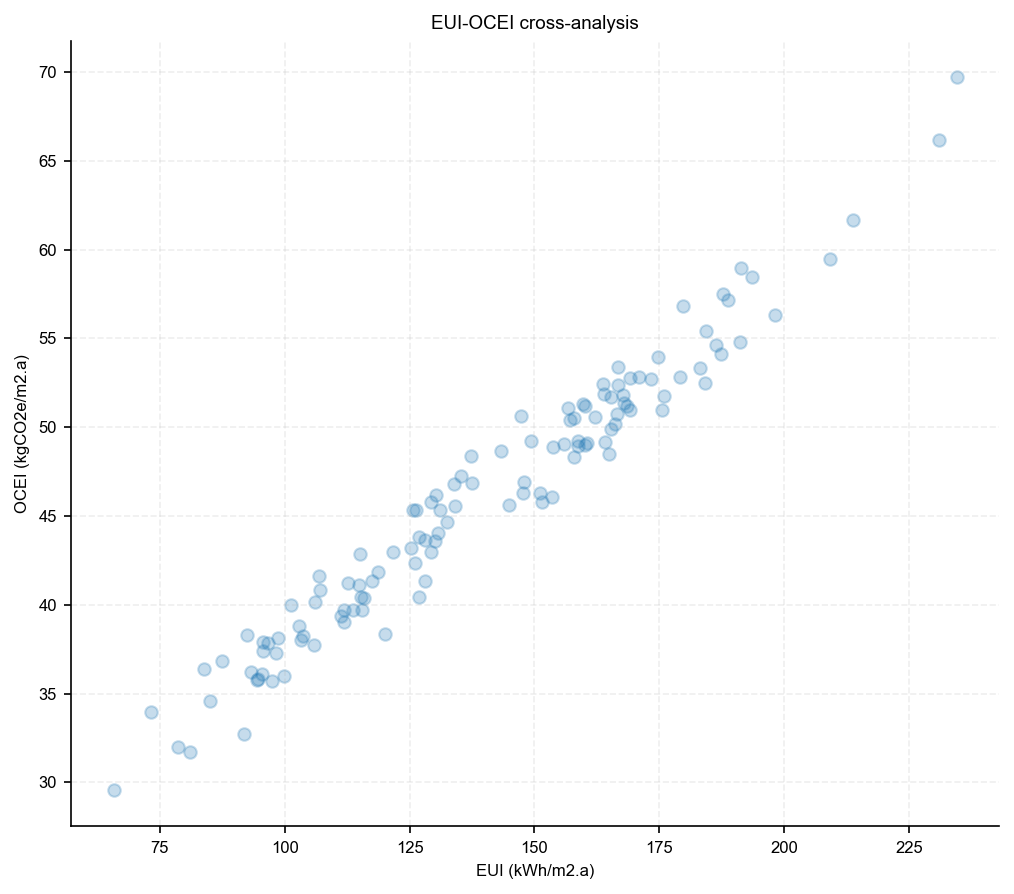

Pearson correlation between EUI and OCEI: r = 0.9791, p = 3.5870e-84
Pearson correlation between carbon_per_kwh and OCEI: r = -0.5369, p = 2.1719e-10


In [12]:
# ---------- EUI-OCEI relationship ----------
from scipy.stats import pearsonr

r_eui_ocei, p_eui_ocei = pearsonr(df["eui_kwh_m2"], df["OCEI_kgco2e_m2"])
r_carbon_factor, p_carbon_factor = pearsonr(df["carbon_per_kwh"], df["OCEI_kgco2e_m2"])

fig, ax = plt.subplots(figsize=(6.8, 6.0))
ax.scatter(df["eui_kwh_m2"], df["OCEI_kgco2e_m2"], alpha=0.25)
ax.set_xlabel("EUI (kWh/m2.a)")
ax.set_ylabel("OCEI (kgCO2e/m2.a)")
ax.set_title("EUI-OCEI cross-analysis")
fig.tight_layout()
fig.savefig(FIG_DIR / "eui_ocei_scatter.png", bbox_inches="tight")
plt.show()

print(f"Pearson correlation between EUI and OCEI: r = {r_eui_ocei:.4f}, p = {p_eui_ocei:.4e}")
print(f"Pearson correlation between carbon_per_kwh and OCEI: r = {r_carbon_factor:.4f}, p = {p_carbon_factor:.4e}")

<!-- CODEx Chinese cell explanation: start -->
### Cell 13 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 13 — Computational step 13

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

,sample_count,top_10pct_n,top10_overlap_ratio,mean_abs_rank_shift,median_abs_rank_shift,max_abs_rank_shift
0,121,12,0.75,5.5868,5.0,20.0


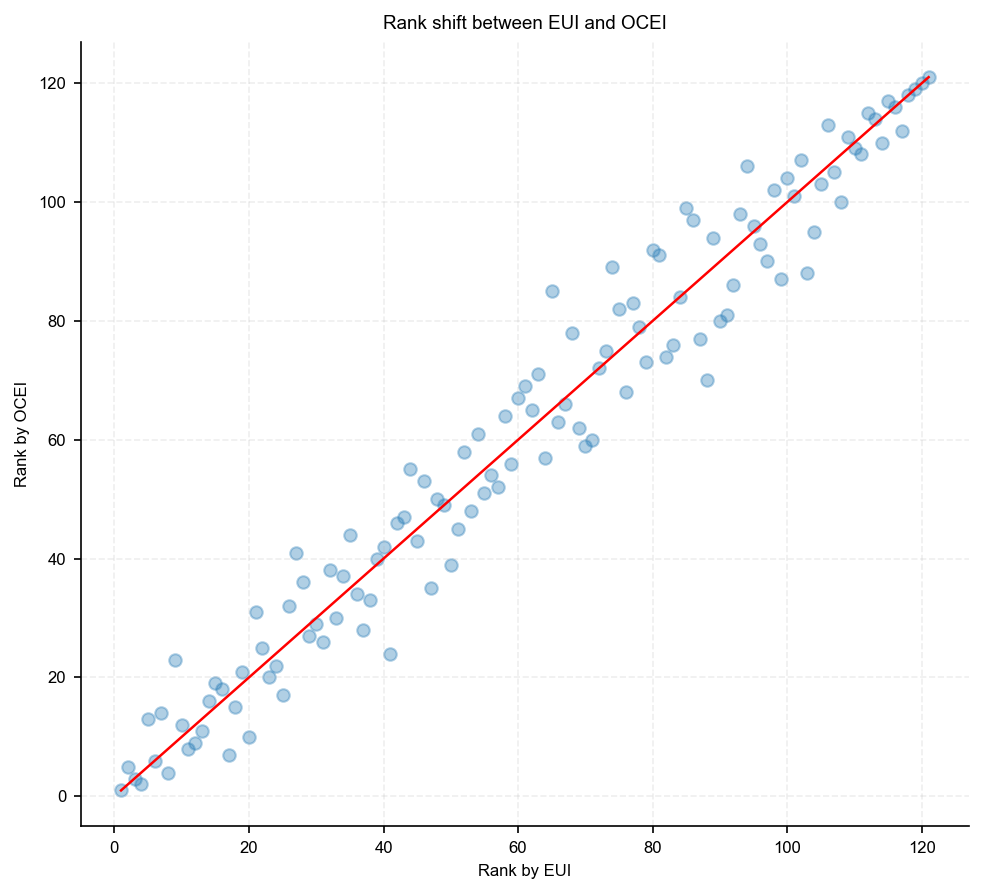

In [13]:
# ---------- 5A) Ranking shift analysis between EUI and OCEI ----------
rank_df = df[["eui_kwh_m2", "OCEI_kgco2e_m2"]].copy()

rank_df["rank_eui"] = rank_df["eui_kwh_m2"].rank(method="first", ascending=True)
rank_df["rank_ocei"] = rank_df["OCEI_kgco2e_m2"].rank(method="first", ascending=True)
rank_df["rank_shift"] = rank_df["rank_ocei"] - rank_df["rank_eui"]
rank_df["abs_rank_shift"] = rank_df["rank_shift"].abs()

top_n = max(1, int(len(rank_df) * 0.10))
top_eui_idx = set(rank_df.nsmallest(top_n, "eui_kwh_m2").index)
top_ocei_idx = set(rank_df.nsmallest(top_n, "OCEI_kgco2e_m2").index)
overlap_ratio = len(top_eui_idx & top_ocei_idx) / top_n

rank_summary = pd.DataFrame([{
    "sample_count": len(rank_df),
    "top_10pct_n": top_n,
    "top10_overlap_ratio": overlap_ratio,
    "mean_abs_rank_shift": rank_df["abs_rank_shift"].mean(),
    "median_abs_rank_shift": rank_df["abs_rank_shift"].median(),
    "max_abs_rank_shift": rank_df["abs_rank_shift"].max(),
}])

rank_summary.to_csv(OUT_DIR / "eui_ocei_rank_shift_summary.csv", index=False, encoding="utf-8-sig")
rank_df.to_csv(OUT_DIR / "eui_ocei_rank_shift_detail.csv", index=False, encoding="utf-8-sig")

display(rank_summary.round(4))

fig, ax = plt.subplots(figsize=(6.6, 6.0))
ax.scatter(rank_df["rank_eui"], rank_df["rank_ocei"], alpha=0.35)
ax.plot([1, len(rank_df)], [1, len(rank_df)], color="red", linewidth=1.2)
ax.set_xlabel("Rank by EUI")
ax.set_ylabel("Rank by OCEI")
ax.set_title("Rank shift between EUI and OCEI")
fig.tight_layout()
fig.savefig(FIG_DIR / "eui_ocei_rank_shift.png", bbox_inches="tight")
plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 14 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 14 — Computational step 14

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [14]:
# ---------- 5B-0) Extend to 20 input variables for EUI-OCEI factor comparison ----------
top20 = [
    "dhw_per_person",
    "floor_num",
    "room_count",
    "footprint_area_m2",
    "dhw_temp",
    "boiler_eff",
    "cop_heating",
    "operation_hours",
    "fresh_air_ach",
    "light_power",
    "wwr",
    "cop_cooling",
    "floor_height",
    "aspect_ratio",
    "equip_power",
    "heat_set",
    "room_area",
    "u_wall",
    "shgc_s",
    "orientation_sin",
]

<!-- CODEx Chinese cell explanation: start -->
### Cell 15 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 15 — Computational step 15

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [15]:
# ---------- 5B-1) Bootstrap-SRC comparison for EUI and OCEI ----------

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

def run_src_model(df_in, feature_list, target, seed=42, B=BOOTSTRAP_N):
    X = df_in[feature_list].copy().replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    y = df_in[target].copy()

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_std = x_scaler.fit_transform(X)
    y_std = y_scaler.fit_transform(y.to_numpy().reshape(-1, 1)).ravel()

    model = LinearRegression()
    model.fit(X_std, y_std)
    coef_full = model.coef_

    rng = np.random.default_rng(seed)
    coef_boot = np.zeros((B, X.shape[1]))

    for b in range(B):
        idx = rng.integers(0, len(X), len(X))
        Xb = X.iloc[idx].reset_index(drop=True)
        yb = y.iloc[idx].reset_index(drop=True)

        Xb_std = StandardScaler().fit_transform(Xb)
        yb_std = StandardScaler().fit_transform(yb.to_numpy().reshape(-1, 1)).ravel()

        mb = LinearRegression()
        mb.fit(Xb_std, yb_std)
        coef_boot[b, :] = mb.coef_

    out = pd.DataFrame({
        "feature": feature_list,
        "SRC": coef_full,
        "abs_SRC": np.abs(coef_full),
        "CI_low": np.quantile(coef_boot, 0.025, axis=0),
        "CI_high": np.quantile(coef_boot, 0.975, axis=0),
    })

    out["sign_stable"] = (
        (out["CI_low"] > 0) | (out["CI_high"] < 0)
    )

    return out.sort_values("abs_SRC", ascending=False).reset_index(drop=True)

compare_features = [c for c in top20 if c in df.columns]

src_eui_cmp = run_src_model(df, compare_features, "eui_kwh_m2", seed=42, B=BOOTSTRAP_N)
src_ocei_cmp = run_src_model(df, compare_features, "OCEI_kgco2e_m2", seed=42, B=BOOTSTRAP_N)

factor_compare_df = (
    src_eui_cmp.rename(columns={
        "SRC": "EUI_SRC",
        "abs_SRC": "abs_EUI_SRC",
        "CI_low": "EUI_CI_low",
        "CI_high": "EUI_CI_high",
        "sign_stable": "EUI_sign_stable"
    })
    .merge(
        src_ocei_cmp.rename(columns={
            "SRC": "OCEI_SRC",
            "abs_SRC": "abs_OCEI_SRC",
            "CI_low": "OCEI_CI_low",
            "CI_high": "OCEI_CI_high",
            "sign_stable": "OCEI_sign_stable"
        }),
        on="feature",
        how="inner"
    )
)

factor_compare_df["delta_abs"] = factor_compare_df["abs_OCEI_SRC"] - factor_compare_df["abs_EUI_SRC"]
factor_compare_df["max_abs"] = factor_compare_df[["abs_EUI_SRC", "abs_OCEI_SRC"]].max(axis=1)

factor_compare_df = factor_compare_df.sort_values("max_abs", ascending=False)
factor_compare_df.to_csv(OUT_DIR / "eui_ocei_factor_compare_bootstrap_src.csv", index=False, encoding="utf-8-sig")
display(factor_compare_df.head(20).round(4))

,feature,EUI_SRC,abs_EUI_SRC,EUI_CI_low,EUI_CI_high,EUI_sign_stable,OCEI_SRC,abs_OCEI_SRC,OCEI_CI_low,OCEI_CI_high,OCEI_sign_stable,delta_abs,max_abs
0,dhw_per_person,0.8077,0.8077,0.7262,0.8926,True,0.7695,0.7695,0.6896,0.8709,True,-0.0382,0.8077
1,floor_num,-0.6923,0.6923,-0.8318,-0.5828,True,-0.6598,0.6598,-0.8114,-0.5562,True,-0.0325,0.6923
2,room_count,0.5526,0.5526,0.4549,0.6785,True,0.5334,0.5334,0.4441,0.6514,True,-0.0192,0.5526
3,footprint_area_m2,-0.4515,0.4515,-0.5469,-0.3461,True,-0.4399,0.4399,-0.5389,-0.3357,True,-0.0116,0.4515
5,operation_hours,0.1084,0.1084,0.0671,0.1484,True,0.2274,0.2274,0.1876,0.2719,True,0.1191,0.2274
4,dhw_temp,0.1743,0.1743,0.1269,0.2339,True,0.1643,0.1643,0.1169,0.2202,True,-0.0100,0.1743
7,wwr,0.0835,0.0835,0.0397,0.1374,True,0.1580,0.1580,0.1137,0.2165,True,0.0745,0.1580
10,light_power,0.0412,0.0412,0.0014,0.0734,True,0.1441,0.1441,0.1095,0.1797,True,0.1029,0.1441
8,fresh_air_ach,0.0662,0.0662,0.0219,0.1084,True,0.1213,0.1213,0.0819,0.1672,True,0.0551,0.1213
9,equip_power,0.0488,0.0488,0.0114,0.0978,True,0.1048,0.1048,0.0682,0.1528,True,0.0560,0.1048


<!-- CODEx Chinese cell explanation: start -->
### Cell 16 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 16 — Computational step 16

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

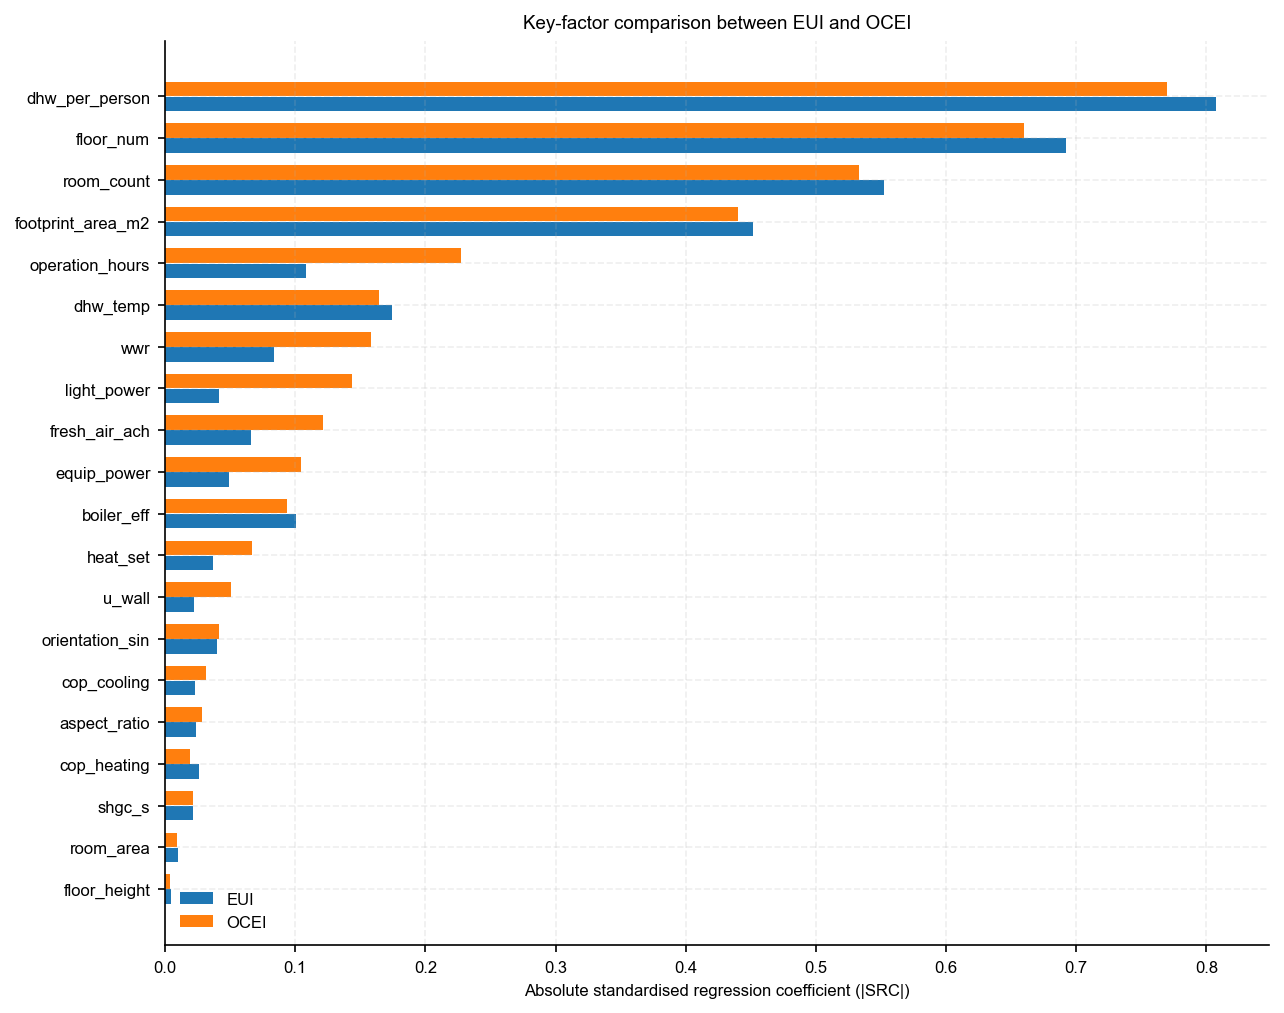

In [16]:
# ---------- 5B) Key-factor comparison between EUI and OCEI ----------
plot_df = factor_compare_df.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8.6, 6.8))
ypos = np.arange(len(plot_df))

ax.barh(ypos - 0.18, plot_df["abs_EUI_SRC"], height=0.35, label="EUI")
ax.barh(ypos + 0.18, plot_df["abs_OCEI_SRC"], height=0.35, label="OCEI")

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["feature"])
ax.set_xlabel("Absolute standardised regression coefficient (|SRC|)")
ax.set_title("Key-factor comparison between EUI and OCEI")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "eui_ocei_factor_compare.png", bbox_inches="tight")
plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 17 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 17 — Computational step 17

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

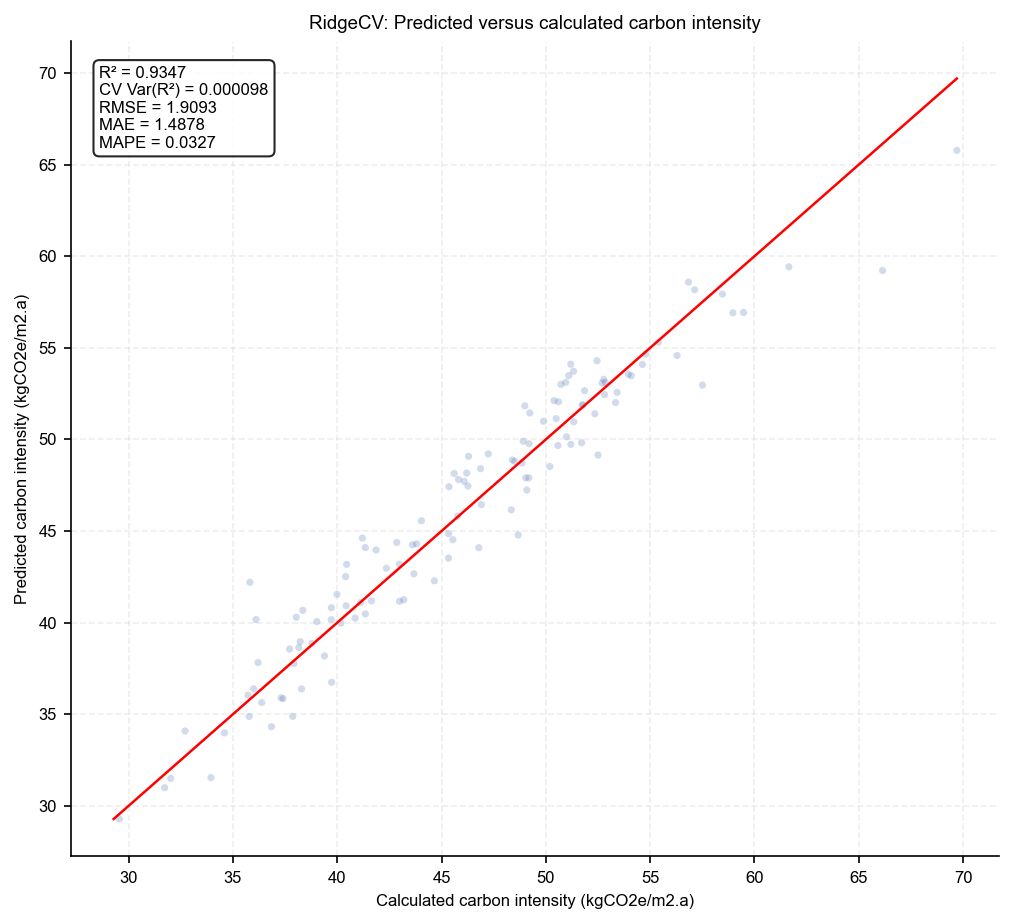

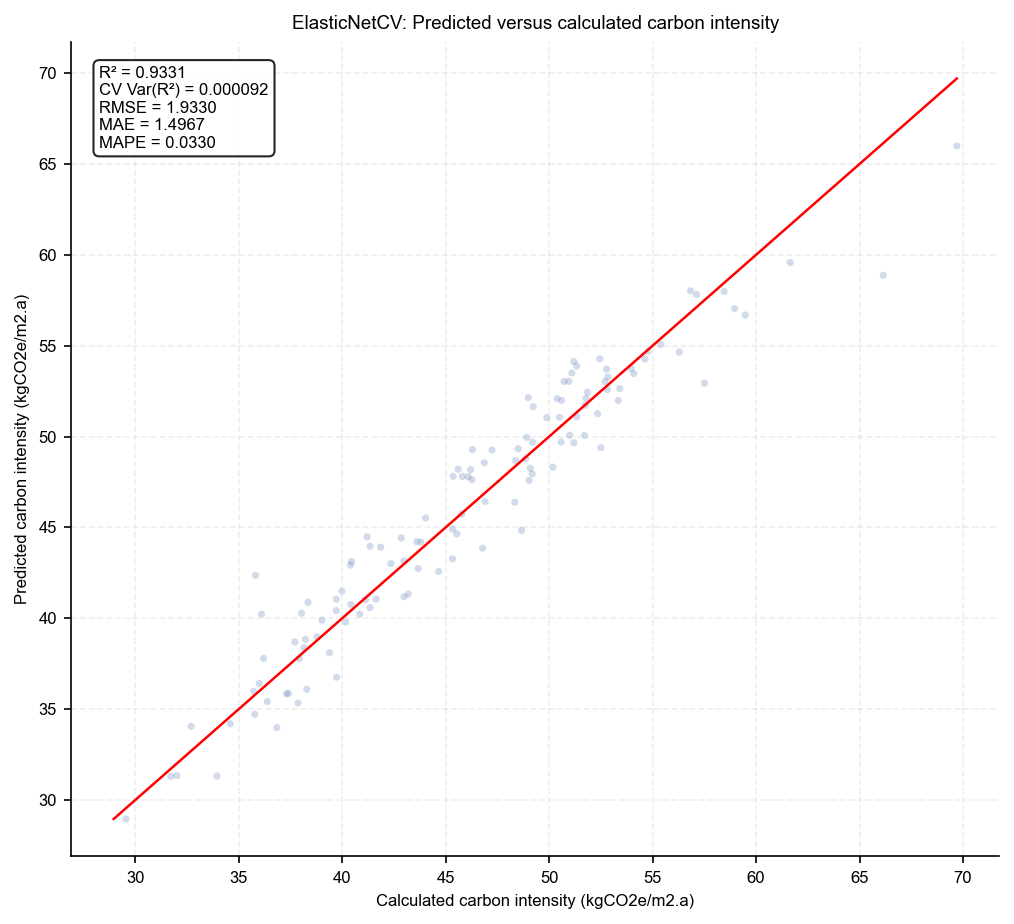

In [17]:
# ---------- 6) Top two models: predicted versus simulated carbon intensity ----------
for name, pred in carbon_oof.items():
    valid = np.isfinite(pred)
    fig, ax = plt.subplots(figsize=(6.8, 6.2))
    ax.scatter(
        y[valid], pred[valid],
        s=12,
        color="#4C72B0",
        alpha=0.25,
        edgecolors="none",
        rasterized=True
    )
    lo = min(y.min(), np.nanmin(pred))
    hi = max(y.max(), np.nanmax(pred))
    ax.plot([lo, hi], [lo, hi], linewidth=1.2, color='red')
    ax.set_title(f"{name}: Predicted versus calculated carbon intensity")
    ax.set_xlabel("Calculated carbon intensity (kgCO2e/m2.a)")
    ax.set_ylabel("Predicted carbon intensity (kgCO2e/m2.a)")
    row = carbon_metrics_df.loc[carbon_metrics_df["model"] == name].iloc[0]

    txt = (
        f"R² = {r2_score(y[valid], pred[valid]):.4f}\n"
        f"CV Var(R²) = {row['cv_r2_variance']:.6f}\n"
        f"RMSE = {np.sqrt(mean_squared_error(y[valid], pred[valid])):.4f}\n"
        f"MAE = {mean_absolute_error(y[valid], pred[valid]):.4f}\n"
        f"MAPE = {mean_absolute_percentage_error(y[valid], pred[valid]):.4f}"
    )
    ax.text(0.03, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85))
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}_carbon_pred_vs_sim.png", bbox_inches="tight")
    plt.show()
